# Movie Revenue Prediction
## Predicting Box-Office Revenue with Machine Learning

**Dataset:** TMDB-5000 Movies (`AiresPucrs/tmdb-5000-movies` on HuggingFace)
**Target:** `log_revenue` (log₁₊ of nominal revenue; also evaluated in original USD)

| Section | What it covers |
|---------|---------------|
| 1 | Configuration — all tunable constants |
| 2 | Data Preprocessing — load → clean → CPI-deflate → features → split → save |
| 3 | Modelling — six feature sets × three model families + hyperparameter tuning |
| 4 | Results — comparison table + bar chart |
| 5 | Feature Importance — which features drive predictions |

> **Tip:** If `processed_dataset.csv` already exists you can skip Section 2 and jump to Section 3.


In [1]:
import ast
import json
import platform
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('Note: shap not installed. Section 5.3 will be skipped. pip install shap to enable.')


C:\Users\danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

Edit constants here — they propagate to every cell below.

In [2]:
# Reproducibility
RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_FOLDS      = 5

# Cast / crew / studio / keyword feature engineering
TOP_ACTORS    = 20
TOP_DIRECTORS = 10
TOP_WRITERS   = 10
TOP_PRODUCERS = 10
TOP_STUDIOS   = 15
TOP_KEYWORDS  = 20

# CPI deflation (BLS CPI-U)
CPI_BASE_YEAR = 2017
CPI_BLS_PATH  = Path('cpi_bls.xlsx')   # file is in the same folder as this notebook

# Hyperparameter tuning (GridSearchCV)
RUN_HYPERPARAMETER_TUNING = True
TUNING_CV = 3

# Output paths
OUTPUT_DIR                = Path('.')
PROCESSED_ALL_PATH        = OUTPUT_DIR / 'processed_dataset.csv'
PROCESSED_TRAIN_PATH      = OUTPUT_DIR / 'processed_train.csv'
PROCESSED_TEST_PATH       = OUTPUT_DIR / 'processed_test.csv'
SUMMARY_PATH              = OUTPUT_DIR / 'dataset_summary.csv'
FEATURE_METADATA_PATH     = OUTPUT_DIR / 'feature_metadata.json'
FINAL_RESULTS_PATH        = OUTPUT_DIR / 'final_all_models.csv'
TOP5_RESULTS_PATH         = OUTPUT_DIR / 'presentation_top5_results.csv'
TOP5_FIGURE_PATH          = OUTPUT_DIR / 'top5_model_test_r2.png'
FEATURE_IMPORTANCE_D_PATH = OUTPUT_DIR / 'top_feature_importance_set_d.csv'
FEATURE_IMPORTANCE_E_PATH = OUTPUT_DIR / 'top_feature_importance_set_e.csv'
SHAP_IMPORTANCE_PATH      = OUTPUT_DIR / 'shap_importance_set_d.csv'
RESOURCE_PATH             = OUTPUT_DIR / 'computational_resources.csv'
TUNING_RESULTS_PATH       = OUTPUT_DIR / 'hyperparameter_tuning_results.csv'


## 2. Data Preprocessing

### 2.1 Helper Functions

In [3]:
def parse_json_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

def extract_names(x):
    items = parse_json_list(x)
    return [item['name'] for item in items if isinstance(item, dict) and 'name' in item]

def extract_crew_by_job(x, target_jobs):
    items = parse_json_list(x)
    return [item.get('name') for item in items
            if isinstance(item, dict) and item.get('job') in target_jobs and item.get('name')]

def extract_directors(x):
    return extract_crew_by_job(x, {'Director'})

def extract_writers(x):
    return extract_crew_by_job(x, {'Writer', 'Screenplay', 'Story', 'Author', 'Novel'})

def extract_producers(x):
    return extract_crew_by_job(x, {'Producer', 'Executive Producer'})

def extract_primary_studio(x):
    items = parse_json_list(x)
    for item in items:
        if isinstance(item, dict) and item.get('name'):
            return item['name']
    return None

def clean_name(name):
    return (str(name)
            .replace(' ', '_').replace('.', '').replace('-', '_')
            .replace("'", '').replace('/', '_').replace(':', '')
            .replace(',', '').replace('(', '').replace(')', '')
            .replace('&', 'and'))

def get_top_items(series, top_k):
    # Call on training data only to avoid leakage
    counter = Counter()
    for items in series:
        counter.update(items)
    return [item for item, _ in counter.most_common(top_k)]

def get_top_singletons(series, top_k):
    # Like get_top_items but for a single-value-per-row column.
    counter = Counter(v for v in series if v)
    return [item for item, _ in counter.most_common(top_k)]

def get_unique_items(series):
    values = set()
    for items in series:
        values.update(items)
    return sorted(values)

def make_indicator_from_list(df, source_col, selected_items, prefix):
    features = pd.DataFrame(index=df.index)
    for item in selected_items:
        col = prefix + clean_name(item)
        features[col] = df[source_col].apply(lambda vals, it=item: int(it in (vals or [])))
    return features

def make_indicator_from_value(df, source_col, selected_items, prefix):
    features = pd.DataFrame(index=df.index)
    for item in selected_items:
        col = prefix + clean_name(item)
        features[col] = (df[source_col] == item).astype(int)
    return features


In [4]:
def build_processed_part(df_part, split_name,
                          train_genres, train_languages,
                          top_actors, top_directors,
                          top_writers, top_producers, top_studios, top_keywords,
                          release_saturation_table):
    # Column choices all come from training data — no test-set leakage
    base = df_part[[
        'id', 'title', 'revenue', 'log_revenue',
        'real_revenue', 'log_real_revenue',
        'budget', 'real_budget',
        'runtime', 'release_year', 'release_month',
        'overview', 'original_language',
    ]].copy()
    base['split'] = split_name

    genre_feats    = make_indicator_from_list(df_part, 'genres_list',   train_genres,  'genre_')
    lang_feats     = pd.DataFrame(
        {f'lang_{clean_name(l)}': (df_part['original_language'] == l).astype(int)
         for l in train_languages},
        index=df_part.index,
    )
    actor_feats    = make_indicator_from_list(df_part, 'cast_list',     top_actors,    'actor_')
    director_feats = make_indicator_from_list(df_part, 'director_list', top_directors, 'director_')
    writer_feats   = make_indicator_from_list(df_part, 'writer_list',   top_writers,   'writer_')
    producer_feats = make_indicator_from_list(df_part, 'producer_list', top_producers, 'producer_')
    keyword_feats  = make_indicator_from_list(df_part, 'keywords_list', top_keywords,  'keyword_')
    studio_feats   = make_indicator_from_value(df_part, 'primary_studio', top_studios, 'studio_')

    count_feats = pd.DataFrame({
        'num_cast':      df_part['cast_list'].apply(len),
        'num_directors': df_part['director_list'].apply(len),
        'num_writers':   df_part['writer_list'].apply(len),
        'num_producers': df_part['producer_list'].apply(len),
        'num_keywords':  df_part['keywords_list'].apply(len),
    }, index=df_part.index)

    # Release-window saturation: for each film, the largest count of training-set films
    # sharing its (release_year, release_month, genre) bucket. Looked up against a table
    # built from train only so test films never inflate counts.
    def lookup_saturation(row):
        if not row['genres_list']:
            return 0
        return max(
            release_saturation_table.get((row['release_year'], row['release_month'], g), 0)
            for g in row['genres_list']
        )
    saturation_feats = pd.DataFrame({
        'release_window_saturation': df_part.apply(lookup_saturation, axis=1),
    }, index=df_part.index)

    return pd.concat(
        [base, genre_feats, lang_feats,
         actor_feats, director_feats, writer_feats, producer_feats,
         keyword_feats, studio_feats, count_feats, saturation_feats],
        axis=1,
    ).reset_index(drop=True)


In [5]:
def load_cpi_series(xlsx_path: Path, base_year: int) -> pd.Series:
    raw = pd.read_excel(xlsx_path, sheet_name=0, header=None)
    header_row = raw[raw[0] == 'Year'].index[0]
    data = raw.iloc[header_row + 1:].copy()
    data.columns = raw.iloc[header_row].tolist()
    data = data[['Year', 'Annual']].copy()
    data['Year']   = pd.to_numeric(data['Year'],   errors='coerce')
    data['Annual'] = pd.to_numeric(data['Annual'], errors='coerce')
    data = data.dropna(subset=['Year'])
    data['Year'] = data['Year'].astype(int)
    cpi = data.set_index('Year')['Annual'].sort_index()
    cpi = cpi.interpolate(method='linear').ffill().bfill()
    cpi = cpi / cpi.loc[base_year] * 100.0
    print(f'CPI loaded: {int(cpi.index.min())}–{int(cpi.index.max())}')
    return cpi

def deflate(nominal, release_year, cpi, base_year):
    cpi_base    = cpi.loc[base_year]
    year_to_cpi = release_year.map(cpi)
    missing     = year_to_cpi.isna()
    if missing.any():
        year_to_cpi = year_to_cpi.fillna(
            release_year.map(
                lambda y: cpi.iloc[cpi.index.get_indexer([y], method='nearest')[0]]
            )
        )
    return nominal * (cpi_base / year_to_cpi)


### 2.2 Load & Clean Dataset

In [6]:
print('Loading dataset from HuggingFace...')
dataset = load_dataset('AiresPucrs/tmdb-5000-movies', split='train')
df = dataset.to_pandas()
print('Original shape:', df.shape)

keep_cols = ['id','title','budget','revenue','runtime','genres',
             'original_language','release_date','overview','status','cast','crew',
             'keywords','production_companies']
keep_cols = [c for c in keep_cols if c in df.columns]
df = df[keep_cols].copy()

before_cleaning_rows = len(df)
df = df[df['status']  == 'Released']
df = df[df['budget']  >  0]
df = df[df['revenue'] >  0]
df = df[df['runtime'].notna() & (df['runtime'] > 0)]
df['overview'] = df['overview'].fillna('')

df['release_date']  = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year']  = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df = df[df['release_year'].notna() & df['release_month'].notna()]
df['release_year']  = df['release_year'].astype(int)
df['release_month'] = df['release_month'].astype(int)

df['log_revenue'] = np.log1p(df['revenue'])

print(f'Rows: {before_cleaning_rows} → {len(df)} after cleaning')


Loading dataset from HuggingFace...


Original shape: (4803, 22)
Rows: 4803 → 3228 after cleaning


### 2.3 CPI Inflation Adjustment

Deflates `budget` and `revenue` to real **2017 USD** using the BLS CPI-U annual series.
Adds `real_revenue`, `real_budget`, `log_real_revenue` columns alongside the nominal ones.
The models in Section 3 use `log_revenue` (nominal) to match existing results, but `log_real_revenue` is available if you want to switch.


In [7]:
print('Loading CPI from:', CPI_BLS_PATH)
cpi_series = load_cpi_series(CPI_BLS_PATH, CPI_BASE_YEAR)

df['real_revenue']     = deflate(df['revenue'], df['release_year'], cpi_series, CPI_BASE_YEAR)
df['real_budget']      = deflate(df['budget'],  df['release_year'], cpi_series, CPI_BASE_YEAR)
df['log_real_revenue'] = np.log1p(df['real_revenue'])

print(f'Nominal revenue mean : ${df["revenue"].mean():>15,.0f}')
print(f'Real revenue mean    : ${df["real_revenue"].mean():>15,.0f}  (in {CPI_BASE_YEAR} USD)')


Loading CPI from: cpi_bls.xlsx
CPI loaded: 1913–2017
Nominal revenue mean : $    121,280,256
Real revenue mean    : $    173,417,892  (in 2017 USD)


C:\Users\danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


### 2.4 Parse Genres, Cast & Crew

In [8]:
df['genres_list']    = df['genres'].apply(extract_names)
df['cast_list']      = df['cast'].apply(extract_names)
df['director_list']  = df['crew'].apply(extract_directors)
df['writer_list']    = df['crew'].apply(extract_writers)
df['producer_list']  = df['crew'].apply(extract_producers)
if 'keywords' in df.columns:
    df['keywords_list'] = df['keywords'].apply(extract_names)
else:
    df['keywords_list'] = [[] for _ in range(len(df))]
if 'production_companies' in df.columns:
    df['primary_studio'] = df['production_companies'].apply(extract_primary_studio)
else:
    df['primary_studio'] = None

print('Sample genres:',    df['genres_list'].iloc[0])
print('Sample cast:',      df['cast_list'].iloc[0][:3])
print('Sample directors:', df['director_list'].iloc[0])
print('Sample writers:',   df['writer_list'].iloc[0][:3])
print('Sample producers:', df['producer_list'].iloc[0][:3])
print('Sample studio:',    df['primary_studio'].iloc[0])
print('Sample keywords:',  df['keywords_list'].iloc[0][:5])


Sample genres: ['Crime', 'Comedy']
Sample cast: ['Tim Roth', 'Antonio Banderas', 'Jennifer Beals']
Sample directors: ['Allison Anders', 'Alexandre Rockwell', 'Robert Rodriguez', 'Quentin Tarantino']
Sample writers: ['Allison Anders', 'Alexandre Rockwell', 'Robert Rodriguez']
Sample producers: ['Alexandre Rockwell', 'Quentin Tarantino', 'Lawrence Bender']
Sample studio: Miramax Films
Sample keywords: ['hotel', "new year's eve", 'witch', 'bet', 'hotel room']


### 2.5 Train / Test Split *(before feature engineering)*

The split happens **before** we decide which actors/directors/genres to encode.
Genres, languages, top actors, and top directors are derived from the **training set only**, then applied to both splits — this prevents test-set information from leaking into the feature schema.


In [9]:
train_raw, test_raw = train_test_split(df, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print('Train:', train_raw.shape, '  Test:', test_raw.shape)

train_genres    = get_unique_items(train_raw['genres_list'])
train_languages = sorted(train_raw['original_language'].dropna().unique().tolist())
top_actors      = get_top_items(train_raw['cast_list'],      TOP_ACTORS)
top_directors   = get_top_items(train_raw['director_list'],  TOP_DIRECTORS)
top_writers     = get_top_items(train_raw['writer_list'],    TOP_WRITERS)
top_producers   = get_top_items(train_raw['producer_list'],  TOP_PRODUCERS)
top_keywords    = get_top_items(train_raw['keywords_list'],  TOP_KEYWORDS)
top_studios     = get_top_singletons(train_raw['primary_studio'], TOP_STUDIOS)

# Release-window saturation table: (year, month, genre) → count of training films.
release_saturation_table = Counter()
for _, row in train_raw.iterrows():
    for g in row['genres_list']:
        release_saturation_table[(row['release_year'], row['release_month'], g)] += 1

print('\nTop actors:',    top_actors)
print('Top directors:', top_directors)
print('Top writers:',   top_writers)
print('Top producers:', top_producers)
print('Top studios:',   top_studios)
print('Top keywords:',  top_keywords)
print(f'\nRelease saturation table: {len(release_saturation_table)} (year, month, genre) buckets')


Train: (2582, 27)   Test: (646, 27)

Top actors: ['Samuel L. Jackson', 'Robert De Niro', 'Matt Damon', 'Morgan Freeman', 'Bruce Willis', 'Liam Neeson', 'Owen Wilson', 'Johnny Depp', 'Nicolas Cage', 'Willem Dafoe', 'Stanley Tucci', 'Sylvester Stallone', 'Steve Buscemi', 'Harrison Ford', 'Brad Pitt', 'John Goodman', 'Paul Rudd', 'George Clooney', 'John Leguizamo', 'Arnold Schwarzenegger']
Top directors: ['Steven Spielberg', 'Ridley Scott', 'Martin Scorsese', 'Clint Eastwood', 'Robert Rodriguez', 'Renny Harlin', 'Robert Zemeckis', 'Steven Soderbergh', 'Peter Farrelly', 'Bobby Farrelly']
Top writers: ['Luc Besson', 'David S. Goyer', 'David Koepp', 'Richard Maibaum', 'Stephen King', 'Robert Mark Kamen', 'John Logan', 'Sylvester Stallone', 'Akiva Goldsman', 'Robert Rodriguez']
Top producers: ['Bob Weinstein', 'Harvey Weinstein', 'Arnon Milchan', 'Steven Spielberg', 'Tim Bevan', 'Joel Silver', 'Eric Fellner', 'Bruce Berman', 'Scott Rudin', 'Neal H. Moritz']
Top studios: ['Paramount Pictures',

### 2.6 Build Processed DataFrames

In [10]:
processed_train = build_processed_part(
    train_raw, 'train', train_genres, train_languages,
    top_actors, top_directors,
    top_writers, top_producers, top_studios, top_keywords,
    release_saturation_table,
)
processed_test  = build_processed_part(
    test_raw, 'test', train_genres, train_languages,
    top_actors, top_directors,
    top_writers, top_producers, top_studios, top_keywords,
    release_saturation_table,
)
processed_df    = pd.concat([processed_train, processed_test], axis=0, ignore_index=True)
processed_df['overview'] = processed_df['overview'].fillna('')

assert list(processed_train.columns) == list(processed_test.columns), 'Column mismatch!'

print('All:', processed_df.shape, '  Train:', processed_train.shape, '  Test:', processed_test.shape)
print('\nMissing values (top 10):')
print(processed_df.isna().sum().sort_values(ascending=False).head(10))


All: (3228, 149)   Train: (2582, 149)   Test: (646, 149)

Missing values (top 10):
id                  0
title               0
revenue             0
log_revenue         0
real_revenue        0
log_real_revenue    0
budget              0
real_budget         0
runtime             0
release_year        0
dtype: int64


### 2.7 Save Outputs

In [11]:
processed_df.to_csv(PROCESSED_ALL_PATH,   index=False)
processed_train.to_csv(PROCESSED_TRAIN_PATH, index=False)
processed_test.to_csv(PROCESSED_TEST_PATH,  index=False)

summary = {
    'dataset_source':         'HuggingFace AiresPucrs/tmdb-5000-movies',
    'original_rows':          len(dataset),
    'rows_before_cleaning':   before_cleaning_rows,
    'cleaned_rows':           len(df),
    'train_rows':             len(processed_train),
    'test_rows':              len(processed_test),
    'test_size':              TEST_SIZE,
    'random_state':           RANDOM_STATE,
    'target':                 'log_revenue',
    'target_reason':          'log1p(revenue) reduces revenue skewness',
    'num_total_columns':      processed_df.shape[1],
    'num_genre_features':     len(train_genres),
    'num_language_features':  len(train_languages),
    'num_actor_features':     len(top_actors),
    'num_director_features':  len(top_directors),
    'num_writer_features':    len(top_writers),
    'num_producer_features':  len(top_producers),
    'num_studio_features':    len(top_studios),
    'num_keyword_features':   len(top_keywords),
    'num_count_features':     5,
    'num_engineered':         1,  # release_window_saturation
    'cleaning_rules':         'Released only; budget>0; revenue>0; runtime>0; valid date.',
    'leakage_control':        ('Actors/directors/writers/producers/studios/keywords/genres/'
                               'languages and saturation table all selected from training data only.'),
}
pd.DataFrame([summary]).to_csv(SUMMARY_PATH, index=False)

feature_metadata = {
    'random_state': RANDOM_STATE, 'test_size': TEST_SIZE,
    'target': 'log_revenue',
    'cpi_base_year': CPI_BASE_YEAR, 'cpi_source': str(CPI_BLS_PATH),
    'train_defined_feature_schema': True,
    'genres_from_train':         train_genres,
    'languages_from_train':      train_languages,
    'top_actors_from_train':     top_actors,
    'top_directors_from_train':  top_directors,
    'top_writers_from_train':    top_writers,
    'top_producers_from_train':  top_producers,
    'top_studios_from_train':    top_studios,
    'top_keywords_from_train':   top_keywords,
}
with open(FEATURE_METADATA_PATH, 'w', encoding='utf-8') as fh:
    json.dump(feature_metadata, fh, indent=2, ensure_ascii=False)

print('Saved:', PROCESSED_ALL_PATH, PROCESSED_TRAIN_PATH, PROCESSED_TEST_PATH)


Saved: processed_dataset.csv processed_train.csv processed_test.csv


## 3. Modelling

### 3.1 Load Processed Data

If you skipped Section 2, the existing `processed_dataset.csv` is loaded here.

In [12]:
df_model = pd.read_csv(PROCESSED_ALL_PATH)
df_model['overview'] = df_model['overview'].fillna('')
print('Loaded:', df_model.shape)
df_model.head(3)


Loaded: (3228, 149)


,id,title,revenue,log_revenue,real_revenue,log_real_revenue,budget,real_budget,runtime,release_year,...,studio_DreamWorks_SKG,studio_Fox_Searchlight_Pictures,studio_Summit_Entertainment,studio_TriStar_Pictures,num_cast,num_directors,num_writers,num_producers,num_keywords,release_window_saturation
0,39691,Cats & Dogs 2 : The Revenge of Kitty Galore,112483764,18.538319,1.264447e+08,18.655315,85000000,9.554977e+07,82.0,2010,...,0,0,0,0,18,1,2,2,4,7
1,31909,Invaders from Mars,4884663,15.401611,1.092453e+07,16.206521,12000000,2.683796e+07,100.0,1986,...,0,0,0,0,28,1,2,2,3,1
2,302699,Central Intelligence,216972543,19.195281,2.215948e+08,19.216361,50000000,5.106518e+07,107.0,2016,...,0,0,0,0,37,1,6,10,6,6


### 3.2 Define Feature Sets

| Set | Features |
|-----|----------|
| **A** | Basic metadata: budget, runtime, release year/month |
| **B** | Set A + genre indicators + language indicators |
| **D** | Set B + actor/director star-power indicators + cast/crew counts |
| **C** | Set B + TF-IDF of movie overview text |
| **C2** | Set B + LDA topics from overview text |
| **E** | Set D + TF-IDF of overview (full combined model) |


In [13]:
basic_features      = ['budget', 'runtime', 'release_year', 'release_month']
genre_columns       = [c for c in df_model.columns if c.startswith('genre_')]
language_columns    = [c for c in df_model.columns if c.startswith('lang_')]
engineered_features = [c for c in ['release_window_saturation'] if c in df_model.columns]
person_columns      = [c for c in df_model.columns
                       if c.startswith('actor_') or c.startswith('director_')
                       or c.startswith('writer_') or c.startswith('producer_')
                       or c.startswith('studio_') or c.startswith('keyword_')
                       or c in ('num_cast', 'num_directors', 'num_writers',
                                'num_producers', 'num_keywords')]

feature_set_a = basic_features
feature_set_b = basic_features + genre_columns + language_columns + engineered_features
feature_set_d = feature_set_b  + person_columns

target = 'log_revenue'

def assert_no_leakage(feats, name):
    overlap = {'revenue', 'log_revenue', 'real_revenue', 'log_real_revenue'} & set(feats)
    assert not overlap, f'Target leakage in {name}: {overlap}'

assert_no_leakage(feature_set_a, 'Set A')
assert_no_leakage(feature_set_b, 'Set B')
assert_no_leakage(feature_set_d, 'Set D')

print('Set A:', len(feature_set_a), 'features')
print('Set B:', len(feature_set_b), 'features (incl.', len(engineered_features), 'engineered)')
print('Set D:', len(feature_set_d), 'features')


Set A: 4 features
Set B: 49 features (incl. 1 engineered)
Set D: 139 features


### 3.3 Prepare Train / Test Sets

- **Test set (20%):** held out, used only for final evaluation
- **Validation:** 5-fold CV on the training set (reported as *Validation* metrics)
- The `split` column was written during preprocessing so the actor/director feature schema was built from train only


In [14]:
if 'split' in df_model.columns and {'train','test'}.issubset(df_model['split'].dropna().unique()):
    train_df = df_model[df_model['split'] == 'train'].copy()
    test_df  = df_model[df_model['split'] == 'test'].copy()
    split_source = 'preprocessing split column'
else:
    train_df, test_df = train_test_split(df_model, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    split_source = 'fallback split inside notebook'

y_train = train_df[target]
y_test  = test_df[target]

print('Split source:', split_source)
print('Train:', train_df.shape, '  Test:', test_df.shape)


Split source: preprocessing split column
Train: (2582, 149)   Test: (646, 149)


### 3.4 Evaluation & Scoring Functions

In [15]:
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scoring = {
    'MAE':  make_scorer(mean_absolute_error, greater_is_better=False),
    'RMSE': make_scorer(rmse_score,          greater_is_better=False),
    'R2':   make_scorer(r2_score),
}

def safe_original_scale_mae(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.clip(np.expm1(y_pred_log), 0, None)
    return mean_absolute_error(y_true, y_pred)

def evaluate_model(model_name, estimator, X_train, y_train, X_test, y_test,
                   numeric_only=False):
    print(f'\n── {model_name} ──')
    if numeric_only:
        X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
        X_test  = X_test.apply(pd.to_numeric,  errors='coerce').fillna(0)

    cv         = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    start_time = time.perf_counter()

    cv_res   = cross_validate(estimator, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    val_mae  = -cv_res['test_MAE'].mean()
    val_rmse = -cv_res['test_RMSE'].mean()
    val_r2   =  cv_res['test_R2'].mean()

    estimator.fit(X_train, y_train)
    y_pred  = estimator.predict(X_test)
    runtime = time.perf_counter() - start_time

    test_mae  = mean_absolute_error(y_test, y_pred)
    test_rmse = rmse_score(y_test, y_pred)
    test_r2   = r2_score(y_test, y_pred)
    orig_mae  = safe_original_scale_mae(y_test, y_pred)

    print(f'  Val  RMSE={val_rmse:.4f}  R²={val_r2:.4f}')
    print(f'  Test RMSE={test_rmse:.4f}  R²={test_r2:.4f}  MAE≈${orig_mae/1e6:.1f}M  ({runtime:.1f}s)')

    return {
        'Model': model_name,
        'Validation_MAE': val_mae, 'Validation_RMSE': val_rmse, 'Validation_R2': val_r2,
        'Test_MAE': test_mae, 'Test_RMSE': test_rmse, 'Test_R2': test_r2,
        'Original_MAE_USD': orig_mae, 'Runtime_sec': runtime,
    }, estimator


### 3.5 Model & Pipeline Constructors

In [16]:
def get_rf(**kw):
    params = dict(n_estimators=300, min_samples_split=5, min_samples_leaf=2,
                  random_state=RANDOM_STATE, n_jobs=-1)
    params.update(kw)
    return RandomForestRegressor(**params)

def get_xgb(**kw):
    params = dict(n_estimators=300, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8,
                  objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=-1)
    params.update(kw)
    return XGBRegressor(**params)

def make_tfidf_preprocessor(metadata_features):
    return ColumnTransformer([
        ('metadata', 'passthrough', metadata_features),
        ('tfidf', TfidfVectorizer(
            max_features=500, stop_words='english',
            min_df=3, max_df=0.8, ngram_range=(1, 2),
        ), 'overview'),
    ])

def make_lda_preprocessor(metadata_features):
    lda_text = Pipeline([
        ('count', CountVectorizer(max_features=1000, stop_words='english', min_df=3, max_df=0.8)),
        ('lda',   LatentDirichletAllocation(
            n_components=10, random_state=RANDOM_STATE, learning_method='batch', max_iter=20)),
    ])
    return ColumnTransformer([
        ('metadata', 'passthrough', metadata_features),
        ('lda', lda_text, 'overview'),
    ])


In [17]:
# Reset accumulators — re-run this cell if you want to rerun all experiments fresh
results       = []
fitted_models = {}


### 3.6 Set A — Baseline + Basic Metadata

`budget`, `runtime`, `release_year`, `release_month`

The `DummyRegressor` (mean prediction) sets the floor — any real model should beat it.

In [18]:
X_train_a = train_df[feature_set_a]
X_test_a  = test_df[feature_set_a]

for name, model in [
    ('Baseline - Mean Prediction', DummyRegressor(strategy='mean')),
    ('Linear Regression - Set A',  LinearRegression()),
]:
    res, fit = evaluate_model(name, model, X_train_a, y_train, X_test_a, y_test, numeric_only=True)
    results.append(res); fitted_models[name] = fit



── Baseline - Mean Prediction ──
  Val  RMSE=2.0904  R²=-0.0022
  Test RMSE=1.9860  R²=-0.0031  MAE≈$93.4M  (1.5s)

── Linear Regression - Set A ──
  Val  RMSE=1.7714  R²=0.2837
  Test RMSE=1.6801  R²=0.2821  MAE≈$112.3M  (1.0s)


### 3.7 Set B — + Genres & Language

Adds one-hot encoded genres and original-language indicators to Set A.

In [19]:
X_train_b = train_df[feature_set_b]
X_test_b  = test_df[feature_set_b]

for name, model in [
    ('Linear Regression - Set B', LinearRegression()),
    ('Ridge - Set B',             Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ('Lasso - Set B',             Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=10000)),
    ('Random Forest - Set B',     get_rf()),
    ('XGBoost - Set B',           get_xgb()),
]:
    res, fit = evaluate_model(name, model, X_train_b, y_train, X_test_b, y_test, numeric_only=True)
    results.append(res); fitted_models[name] = fit



── Linear Regression - Set B ──
  Val  RMSE=1.7372  R²=0.3106
  Test RMSE=1.6639  R²=0.2959  MAE≈$101.5M  (0.9s)

── Ridge - Set B ──
  Val  RMSE=1.7321  R²=0.3150
  Test RMSE=1.6609  R²=0.2984  MAE≈$101.7M  (0.0s)

── Lasso - Set B ──
  Val  RMSE=1.7304  R²=0.3164
  Test RMSE=1.6628  R²=0.2968  MAE≈$101.5M  (0.0s)

── Random Forest - Set B ──


C:\Users\danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.93435e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


  Val  RMSE=1.5106  R²=0.4772
  Test RMSE=1.4613  R²=0.4570  MAE≈$64.1M  (1.7s)

── XGBoost - Set B ──
  Val  RMSE=1.4977  R²=0.4859
  Test RMSE=1.5024  R²=0.4260  MAE≈$63.8M  (0.7s)


### 3.8 Set D — + Cast/Crew Star Power

Adds binary indicators for the top 20 actors and top 10 directors (selected from train only), plus `num_cast` and `num_directors` count features.

In [20]:
X_train_d = train_df[feature_set_d]
X_test_d  = test_df[feature_set_d]

for name, model in [
    ('Linear Regression - Set D Cast/Crew', LinearRegression()),
    ('Ridge - Set D Cast/Crew',             Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ('Lasso - Set D Cast/Crew',             Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=10000)),
    ('Random Forest - Set D Cast/Crew',     get_rf()),
    ('XGBoost - Set D Cast/Crew',           get_xgb()),
]:
    res, fit = evaluate_model(name, model, X_train_d, y_train, X_test_d, y_test, numeric_only=True)
    results.append(res); fitted_models[name] = fit



── Linear Regression - Set D Cast/Crew ──
  Val  RMSE=1.6284  R²=0.3946
  Test RMSE=1.6345  R²=0.3206  MAE≈$103.7M  (0.2s)

── Ridge - Set D Cast/Crew ──
  Val  RMSE=1.6192  R²=0.4018
  Test RMSE=1.6254  R²=0.3281  MAE≈$102.2M  (0.1s)

── Lasso - Set D Cast/Crew ──


C:\Users\danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.88195e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


  Val  RMSE=1.6166  R²=0.4038
  Test RMSE=1.6183  R²=0.3340  MAE≈$97.8M  (0.2s)

── Random Forest - Set D Cast/Crew ──
  Val  RMSE=1.4186  R²=0.5400
  Test RMSE=1.3651  R²=0.5261  MAE≈$60.0M  (3.7s)

── XGBoost - Set D Cast/Crew ──
  Val  RMSE=1.4071  R²=0.5472
  Test RMSE=1.4186  R²=0.4882  MAE≈$62.2M  (0.9s)


### 3.9 Set C — + TF-IDF Text Features

Combines Set B metadata with up to 500 TF-IDF terms (unigrams + bigrams) from the movie overview. Linear regression is skipped here — it does not scale well to 500 sparse text dimensions without regularisation.

In [21]:
X_train_c = train_df[feature_set_b + ['overview']]
X_test_c  = test_df[feature_set_b  + ['overview']]
tfidf_prep_c = make_tfidf_preprocessor(feature_set_b)

for name, model in [
    ('Random Forest - Set C TF-IDF', get_rf()),
    ('XGBoost - Set C TF-IDF',       get_xgb()),
]:
    pipeline = Pipeline([('features', tfidf_prep_c), ('model', model)])
    res, fit = evaluate_model(name, pipeline, X_train_c, y_train, X_test_c, y_test)
    results.append(res); fitted_models[name] = fit



── Random Forest - Set C TF-IDF ──
  Val  RMSE=1.5302  R²=0.4636
  Test RMSE=1.4126  R²=0.4925  MAE≈$62.2M  (18.7s)

── XGBoost - Set C TF-IDF ──
  Val  RMSE=1.5393  R²=0.4571
  Test RMSE=1.5181  R²=0.4139  MAE≈$65.0M  (2.9s)


### 3.10 Set C2 — + LDA Topic Features

Reduces the overview text to 10 latent topics via LDA, then appends those topic weights to Set B metadata. More compact than TF-IDF but loses term-level specificity.

In [22]:
lda_prep = make_lda_preprocessor(feature_set_b)

for name, model in [
    ('Random Forest - Set C2 LDA', get_rf()),
    ('XGBoost - Set C2 LDA',       get_xgb()),
]:
    pipeline = Pipeline([('features', lda_prep), ('model', model)])
    res, fit = evaluate_model(name, pipeline, X_train_c, y_train, X_test_c, y_test)
    results.append(res); fitted_models[name] = fit



── Random Forest - Set C2 LDA ──
  Val  RMSE=1.5156  R²=0.4744
  Test RMSE=1.4563  R²=0.4606  MAE≈$63.6M  (15.7s)

── XGBoost - Set C2 LDA ──
  Val  RMSE=1.5381  R²=0.4584
  Test RMSE=1.4881  R²=0.4368  MAE≈$63.5M  (12.3s)


### 3.11 Set E — Full Combined Model

Set D (metadata + cast/crew) + TF-IDF text. Best-performing configuration in the experiments.

In [23]:
X_train_e = train_df[feature_set_d + ['overview']]
X_test_e  = test_df[feature_set_d  + ['overview']]
tfidf_prep_e = make_tfidf_preprocessor(feature_set_d)

for name, model in [
    ('Random Forest - Set E Cast/Crew + TF-IDF', get_rf()),
    ('XGBoost - Set E Cast/Crew + TF-IDF',       get_xgb()),
]:
    pipeline = Pipeline([('features', tfidf_prep_e), ('model', model)])
    res, fit = evaluate_model(name, pipeline, X_train_e, y_train, X_test_e, y_test)
    results.append(res); fitted_models[name] = fit



── Random Forest - Set E Cast/Crew + TF-IDF ──
  Val  RMSE=1.4402  R²=0.5258
  Test RMSE=1.3470  R²=0.5386  MAE≈$59.9M  (20.2s)

── XGBoost - Set E Cast/Crew + TF-IDF ──
  Val  RMSE=1.4397  R²=0.5263
  Test RMSE=1.4421  R²=0.4711  MAE≈$60.8M  (3.1s)


### 3.12 Set E — Stacking Ensemble

Stacks Random Forest + XGBoost (Set E features) with **Ridge** as the final
estimator. Uses the same TF-IDF preprocessor as Set E so the comparison is
direct against the individual base learners.


In [24]:
estimators = [
    ('rf',  get_rf()),
    ('xgb', get_xgb()),
]
stacking_pipe = Pipeline([
    ('features', make_tfidf_preprocessor(feature_set_d)),
    ('model',    StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=1.0, random_state=RANDOM_STATE),
        cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=-1,
    )),
])
res, fit = evaluate_model(
    'Stacking (RF+XGB->Ridge) - Set E', stacking_pipe,
    X_train_e, y_train, X_test_e, y_test,
)
results.append(res); fitted_models[res['Model']] = fit



── Stacking (RF+XGB->Ridge) - Set E ──
  Val  RMSE=1.4272  R²=0.5342
  Test RMSE=1.3804  R²=0.5154  MAE≈$60.3M  (100.1s)


### 3.13 Hyperparameter Tuning (Set E)

`GridSearchCV` with 3-fold CV over a small grid each for RF and XGBoost.
Best params are applied and the tuned models are evaluated on the held-out test set.
Set `RUN_HYPERPARAMETER_TUNING = False` in Section 1 to skip.


In [25]:
hyperparameter_records = []

if RUN_HYPERPARAMETER_TUNING:
    cv_tuning = KFold(n_splits=TUNING_CV, shuffle=True, random_state=RANDOM_STATE)

    # ── Tuned Random Forest (GridSearchCV) ────────────────────────────────────
    rf_pipe = Pipeline([
        ('features', make_tfidf_preprocessor(feature_set_d)),
        ('model',    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    ])
    rf_param_grid = {
        'model__n_estimators':     [200, 400],
        'model__max_depth':        [None, 16],
        'model__min_samples_leaf': [1, 2],
    }
    rf_search = GridSearchCV(rf_pipe, rf_param_grid,
                             cv=cv_tuning, scoring='neg_root_mean_squared_error',
                             n_jobs=-1)
    rf_search.fit(X_train_e, y_train)
    print('RF best params:', rf_search.best_params_)
    hyperparameter_records.append({
        'Model': 'Tuned Random Forest - Set E',
        'Best_Params': json.dumps(rf_search.best_params_),
        'Best_Validation_RMSE': -rf_search.best_score_,
    })
    res, fit = evaluate_model('Tuned Random Forest - Set E Cast/Crew + TF-IDF',
                               rf_search.best_estimator_, X_train_e, y_train, X_test_e, y_test)
    results.append(res); fitted_models[res['Model']] = fit

    # ── Tuned XGBoost (GridSearchCV) ──────────────────────────────────────────
    xgb_pipe = Pipeline([
        ('features', make_tfidf_preprocessor(feature_set_d)),
        ('model',    XGBRegressor(objective='reg:squarederror',
                                   random_state=RANDOM_STATE, n_jobs=-1)),
    ])
    xgb_param_grid = {
        'model__n_estimators':  [200, 400],
        'model__learning_rate': [0.05, 0.10],
        'model__max_depth':     [3, 5],
    }
    xgb_search = GridSearchCV(xgb_pipe, xgb_param_grid,
                              cv=cv_tuning, scoring='neg_root_mean_squared_error',
                              n_jobs=-1)
    xgb_search.fit(X_train_e, y_train)
    print('XGB best params:', xgb_search.best_params_)
    hyperparameter_records.append({
        'Model': 'Tuned XGBoost - Set E',
        'Best_Params': json.dumps(xgb_search.best_params_),
        'Best_Validation_RMSE': -xgb_search.best_score_,
    })
    res, fit = evaluate_model('Tuned XGBoost - Set E Cast/Crew + TF-IDF',
                               xgb_search.best_estimator_, X_train_e, y_train, X_test_e, y_test)
    results.append(res); fitted_models[res['Model']] = fit

    pd.DataFrame(hyperparameter_records).to_csv(TUNING_RESULTS_PATH, index=False)
    print('Tuning results saved.')
else:
    print('Skipped. Set RUN_HYPERPARAMETER_TUNING = True in Section 1 to enable.')


RF best params: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 400}

── Tuned Random Forest - Set E Cast/Crew + TF-IDF ──
  Val  RMSE=1.4440  R²=0.5233
  Test RMSE=1.3396  R²=0.5436  MAE≈$59.8M  (28.2s)
XGB best params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200}

── Tuned XGBoost - Set E Cast/Crew + TF-IDF ──
  Val  RMSE=1.4620  R²=0.5103
  Test RMSE=1.4934  R²=0.4328  MAE≈$60.9M  (3.7s)
Tuning results saved.


## 4. Results Summary

In [26]:
results_df = pd.DataFrame(results)[[
    'Model','Validation_MAE','Validation_RMSE','Validation_R2',
    'Test_MAE','Test_RMSE','Test_R2','Original_MAE_USD','Runtime_sec'
]].sort_values('Test_R2', ascending=False).reset_index(drop=True)

results_df.to_csv(FINAL_RESULTS_PATH, index=False)
results_df.head(5)[['Model','Test_R2','Test_RMSE','Original_MAE_USD','Runtime_sec']].to_csv(
    TOP5_RESULTS_PATH, index=False)

display(results_df[['Model','Test_R2','Test_RMSE','Original_MAE_USD','Runtime_sec']])


,Model,Test_R2,Test_RMSE,Original_MAE_USD,Runtime_sec
0,Tuned Random Forest - Set E Cast/Crew + TF-IDF,0.543640,1.339563,5.975762e+07,28.240411
1,Random Forest - Set E Cast/Crew + TF-IDF,0.538568,1.346986,5.989632e+07,20.225298
2,Random Forest - Set D Cast/Crew,0.526102,1.365059,6.004177e+07,3.734749
3,Stacking (RF+XGB->Ridge) - Set E,0.515403,1.380383,6.034877e+07,100.123045
4,Random Forest - Set C TF-IDF,0.492518,1.412601,6.221882e+07,18.701637
5,XGBoost - Set D Cast/Crew,0.488219,1.418572,6.218665e+07,0.893832
6,XGBoost - Set E Cast/Crew + TF-IDF,0.471068,1.442146,6.078256e+07,3.057207
7,Random Forest - Set C2 LDA,0.460617,1.456323,6.357958e+07,15.703312
8,Random Forest - Set B,0.456961,1.461251,6.408590e+07,1.678105
9,XGBoost - Set C2 LDA,0.436834,1.488083,6.354712e+07,12.320135


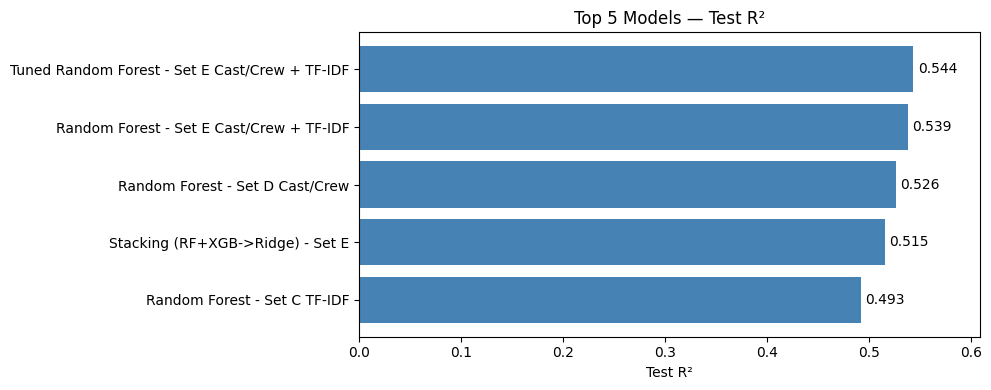

In [27]:
top_plot = results_df.head(5).sort_values('Test_R2', ascending=True)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(top_plot['Model'], top_plot['Test_R2'], color='steelblue')
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_xlabel('Test R²')
ax.set_title('Top 5 Models — Test R²')
ax.set_xlim(0, top_plot['Test_R2'].max() * 1.12)
plt.tight_layout()
plt.savefig(TOP5_FIGURE_PATH, dpi=300, bbox_inches='tight')
plt.show()


In [28]:
resource_info = {
    'python_version': platform.python_version(),
    'system': platform.system(), 'machine': platform.machine(),
    'processor': platform.processor(),
    'split_source': split_source,
    'validation_strategy': f'{N_FOLDS}-fold cross-validation on training set',
    'test_size': TEST_SIZE, 'random_state': RANDOM_STATE,
    'hyperparameter_tuning': RUN_HYPERPARAMETER_TUNING,
    'tuning_strategy': 'GridSearchCV',
    'tuning_cv': TUNING_CV if RUN_HYPERPARAMETER_TUNING else 0,
}
pd.DataFrame([resource_info]).to_csv(RESOURCE_PATH, index=False)
print('Computational resources saved.')


Computational resources saved.


## 5. Feature Importance

### 5.1 Set D — Structured Features Only

Clean, interpretable importances from the Set D Random Forest (no text features).

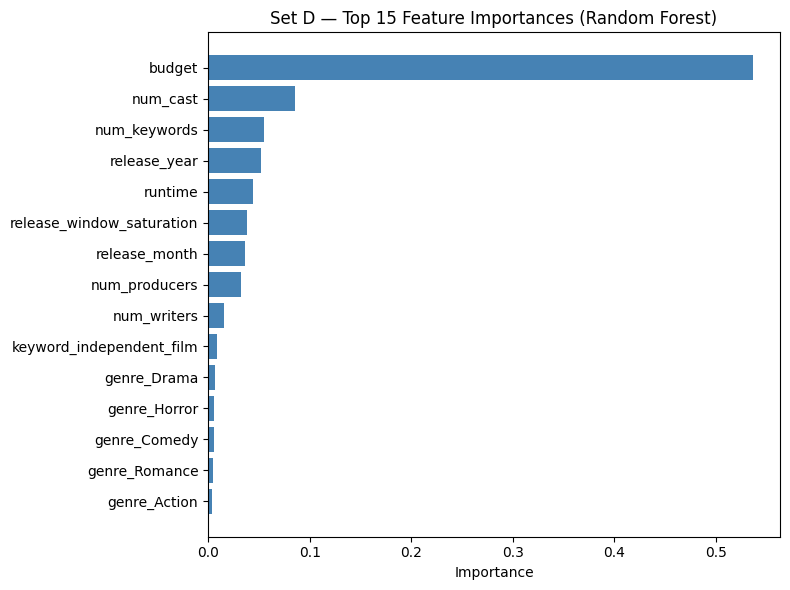

In [29]:
rf_d = fitted_models['Random Forest - Set D Cast/Crew']
importance_d = pd.DataFrame({
    'feature':    feature_set_d,
    'importance': rf_d.feature_importances_,
}).sort_values('importance', ascending=False)

importance_d.head(20).to_csv(FEATURE_IMPORTANCE_D_PATH, index=False)

top_d = importance_d.head(15).sort_values('importance')
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_d['feature'], top_d['importance'], color='steelblue')
ax.set_title('Set D — Top 15 Feature Importances (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


### 5.2 Set E — Combined Model (Metadata + Cast/Crew + TF-IDF)

Budget still dominates; TF-IDF terms each contribute a small amount individually.

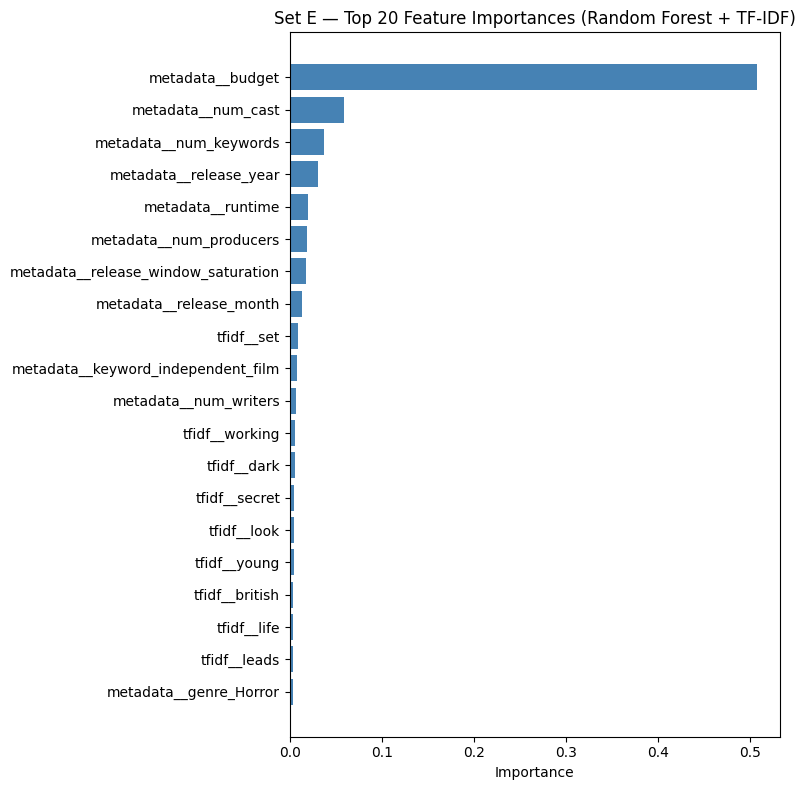

Saved: top_feature_importance_set_e.csv


In [30]:
try:
    rf_e_pipe = Pipeline([
        ('features', make_tfidf_preprocessor(feature_set_d)),
        ('model',    get_rf()),
    ])
    rf_e_pipe.fit(X_train_e, y_train)
    feat_names_e  = rf_e_pipe.named_steps['features'].get_feature_names_out()
    importances_e = rf_e_pipe.named_steps['model'].feature_importances_

    importance_e = pd.DataFrame(
        {'feature': feat_names_e, 'importance': importances_e}
    ).sort_values('importance', ascending=False)

    importance_e.head(30).to_csv(FEATURE_IMPORTANCE_E_PATH, index=False)

    top_e = importance_e.head(20).sort_values('importance')
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.barh(top_e['feature'], top_e['importance'], color='steelblue')
    ax.set_title('Set E — Top 20 Feature Importances (Random Forest + TF-IDF)')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    print('Saved:', FEATURE_IMPORTANCE_E_PATH)
except Exception as exc:
    print('Could not compute Set E feature importance:', exc)


### 5.3 SHAP Feature Importance (Set D)

Uses TreeSHAP on the Set D Random Forest. SHAP attributes a contribution
to each feature *per prediction*; mean |SHAP| across the test sample gives
a more faithful global ranking than impurity-based `feature_importances_`.

Sample is capped at 500 test rows for speed.


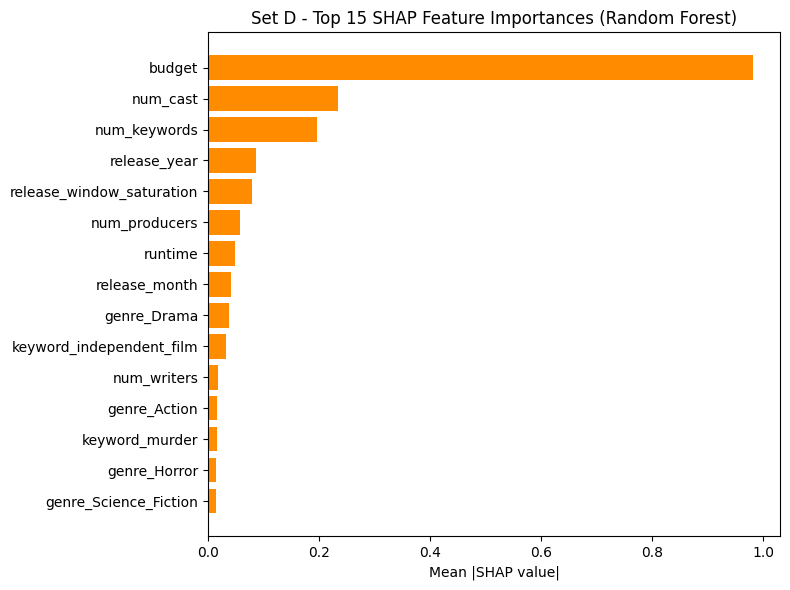

Saved: shap_importance_set_d.csv


In [31]:
if SHAP_AVAILABLE:
    rf_d = fitted_models['Random Forest - Set D Cast/Crew']

    X_test_d_num = test_df[feature_set_d].apply(pd.to_numeric, errors='coerce').fillna(0)
    sample = X_test_d_num.sample(min(500, len(X_test_d_num)), random_state=RANDOM_STATE)

    explainer   = shap.TreeExplainer(rf_d)
    shap_values = explainer.shap_values(sample)
    mean_abs    = np.abs(shap_values).mean(axis=0)

    shap_df = pd.DataFrame({
        'feature':       feature_set_d,
        'mean_abs_shap': mean_abs,
    }).sort_values('mean_abs_shap', ascending=False)
    shap_df.head(20).to_csv(SHAP_IMPORTANCE_PATH, index=False)

    top_shap = shap_df.head(15).sort_values('mean_abs_shap')
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top_shap['feature'], top_shap['mean_abs_shap'], color='darkorange')
    ax.set_title('Set D - Top 15 SHAP Feature Importances (Random Forest)')
    ax.set_xlabel('Mean |SHAP value|')
    plt.tight_layout()
    plt.show()
    print('Saved:', SHAP_IMPORTANCE_PATH)
else:
    print('SHAP not installed - skipping. pip install shap to enable.')
